In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

In [4]:
num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100

In [6]:
Q = np.zeros((n_states, n_actions))
episode_rewards = []

In [7]:
def epsilon_greedy_action(state, epsilon):

    # Explore
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploit
    return np.argmax(Q[state])

In [8]:
def generate_episode(epsilon):
    """
    Generates one episode using the current epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):

        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode

In [12]:
epsilon = epsilon_start

for episode_num in range(num_episodes):

    # Generate one complete episode
    episode = generate_episode(epsilon)

    # Calculate total reward
    total_reward = sum(
        reward for _, _, reward in episode
    )

    episode_rewards.append(total_reward)

    # Return
    G = 0

    # Used for first-visit Monte Carlo
    visited = set()

    # Process episode backwards
    for t in reversed(range(len(episode))):

        state, action, reward = episode[t]

        # Calculate return
        G = gamma * G + reward

        # First-visit MC
        if (state, action) not in visited:

            visited.add((state, action))

            # Update Q-value
            Q[state, action] += alpha * (
                G - Q[state, action]
            )

    # Decay epsilon
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

In [13]:
optimal_policy = np.argmax(Q, axis=1)

state_values = np.max(Q, axis=1)

In [14]:
def print_policy(policy):

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("Name: Meyyappan")
    print("Register Number: 212223240086")

    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):

    print("\nEstimated State-Value Function:")

    print(
        np.round(
            values.reshape(4, 4),
            3
        )
    )

In [15]:
print("\nFinal Q-table:")

print(
    np.round(Q, 3)
)

print_value_function(state_values)

print_policy(optimal_policy)


Final Q-table:
[[0.646 0.937 0.626 0.651]
 [0.637 0.    0.227 0.303]
 [0.417 0.479 0.436 0.412]
 [0.459 0.    0.325 0.426]
 [0.755 0.946 0.    0.691]
 [0.    0.    0.    0.   ]
 [0.    0.827 0.    0.668]
 [0.    0.    0.    0.   ]
 [0.832 0.    0.963 0.83 ]
 [0.888 0.975 0.881 0.   ]
 [0.94  0.99  0.    0.862]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.947 0.99  0.944]
 [0.962 0.989 1.    0.979]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.937 0.637 0.479 0.459]
 [0.946 0.    0.827 0.   ]
 [0.963 0.975 0.99  0.   ]
 [0.    0.99  1.    0.   ]]
Name: Meyyappan
Register Number: 212223240086

Learned Policy:
[['D' 'L' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'D' 'D' 'L']
 ['L' 'R' 'R' 'L']]


In [16]:
success_rate = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    success_rate
)


Average reward over last 1000 episodes: 0.945


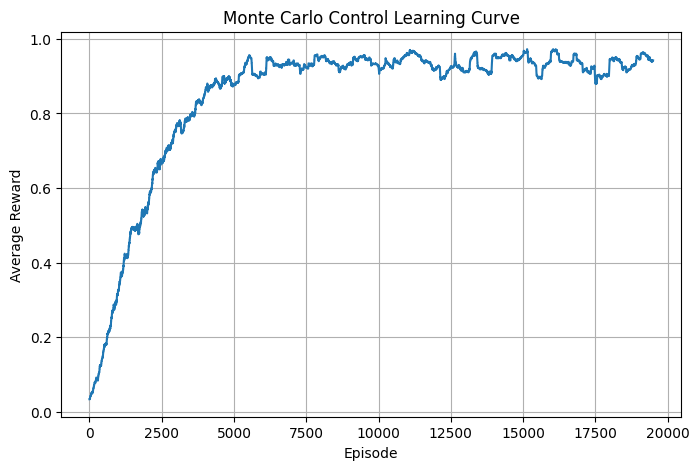

In [17]:

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)


plt.figure(figsize=(8, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "Monte Carlo Control Learning Curve"
)

plt.grid(True)

plt.show()

In [18]:
env.close()